# Isolation Forest

## O que é?

Detecção de anomalias: funciona isolando observações através de divisões aleatórias dos dados. 

## Como funciona?
Dados mais raros (anomalias): mais fáceis de isolar
Dados mais frequentes (normais): mais difíceis de isolar

Ideia: construir árvores de isolamento onde anomalias requerem menos divisões para serem isoladas

# Configurações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, 
                           classification_report,
                           precision_score, recall_score, f1_score)
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE

plt.style.use('default')
sns.set_palette("husl")

/Users/nicole.petrica/Workspace/Studies/credit-card-fraud/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('../data/input/creditcard_clean.csv')

# Pré-Processamento

In [3]:
features = df.columns[:-1]  
target = df.columns[-1]

print(f'Features: {features}')
print(f'Target: {target}')

Features: Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount'],
      dtype='object')
Target: Class


In [ ]:
y = df['Class']
X = df.drop('Class', axis=1)

print(f"Total de amostras: {len(X)}")
print(f"Dados normais: {np.sum(y == 0)} ({np.mean(y == 0)*100:.3f}%)")
print(f"Fraudes: {np.sum(y == 1)} ({np.mean(y == 1)*100:.3f}%)")

Total de amostras: 283726
Dados normais: 283253 (99.833%)
Fraudes: 473 (0.167%)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [6]:
def calculate_metrics(y_true, y_pred, model_name):
    if np.any(y_pred == -1):
        y_pred_binary = np.where(y_pred == -1, 1, 0)
    else:
        y_pred_binary = y_pred
    
    report = classification_report(y_true, y_pred_binary, output_dict=True, zero_division=0)
    return {
        "Modelo": model_name,
        "Precision": report["1"]["precision"],
        "Recall": report["1"]["recall"],
        "F1": report["1"]["f1-score"],
    }

# Isolation Forest Normal

**`contamination`:**
- Proporção esperada de anomalias

In [8]:
fraud_proportion = np.mean(y_train == 1)
print(f"Proporção de fraudes no treino: {fraud_proportion:.4f} ({fraud_proportion*100:.2f}%)")

Proporção de fraudes no treino: 0.0017 (0.17%)


In [9]:
iso_normal = IsolationForest(
    contamination=fraud_proportion,
    random_state=42,
    n_estimators=100
)

In [10]:
iso_normal.fit(X_train)

print("Modelo Isolation Forest treinado!")
print(f"Número de estimadores: {iso_normal.n_estimators}")
print(f"Contamination: {iso_normal.contamination}")

Modelo Isolation Forest treinado!
Número de estimadores: 100
Contamination: 0.0016653449643140364


In [11]:
y_pred_normal = iso_normal.predict(X_test)
scores_normal = iso_normal.decision_function(X_test)

print(f"Anomalias detectadas no teste: {np.sum(y_pred_normal == -1)}")
print(f"Fraudes reais no teste: {np.sum(y_test == 1)}")
print(f"Score médio anomalias: {scores_normal[y_test==1].mean():.3f}")
print(f"Score médio normais: {scores_normal[y_test==0].mean():.3f}")

Anomalias detectadas no teste: 98
Fraudes reais no teste: 95
Score médio anomalias: 0.087
Score médio normais: 0.251


In [12]:
y_pred_normal_train = iso_normal.predict(X_train)
results_normal_train = calculate_metrics(y_train, y_pred_normal_train, "Isolation Forest Normal")
print("Resultados no Treino:")
print(results_normal_train)

Resultados no Treino:
{'Modelo': 'Isolation Forest Normal', 'Precision': 0.23809523809523808, 'Recall': 0.23809523809523808, 'F1': 0.23809523809523808}


In [13]:
results_normal = calculate_metrics(y_test, y_pred_normal, "Isolation Forest Normal")
print("Resultados no Teste:")
print(results_normal)

Resultados no Teste:
{'Modelo': 'Isolation Forest Normal', 'Precision': 0.1836734693877551, 'Recall': 0.18947368421052632, 'F1': 0.18652849740932642}


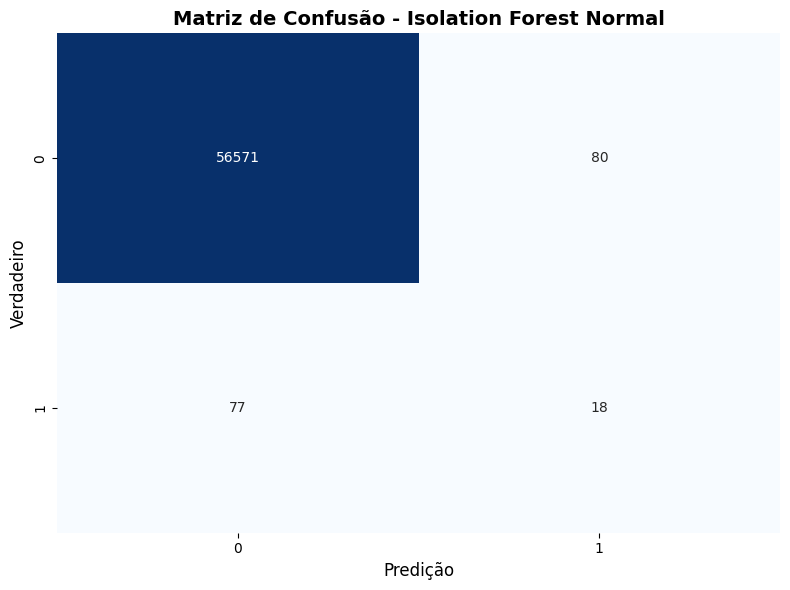

In [14]:
y_pred_binary = np.where(y_pred_normal == -1, 1, 0)
cm_normal = confusion_matrix(y_test, y_pred_binary)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_normal, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusão - Isolation Forest Normal', fontsize=14, fontweight='bold')
plt.ylabel('Verdadeiro', fontsize=12)
plt.xlabel('Predição', fontsize=12)
plt.tight_layout()
plt.show()

# Isolation Forest com Balanceamento

Testando valores de `contamination`

In [15]:
iso_balanced = IsolationForest(
    contamination=0.01,
    random_state=42,
    n_estimators=100
)

In [16]:
iso_balanced.fit(X_train)
y_pred_balanced = iso_balanced.predict(X_test)
scores_balanced = iso_balanced.decision_function(X_test)

In [17]:

print(f"Anomalias detectadas: {np.sum(y_pred_balanced == -1)}")
print(f"Fraudes reais: {np.sum(y_test == 1)}")

Anomalias detectadas: 616
Fraudes reais: 95


In [18]:
results_balanced = calculate_metrics(y_test, y_pred_balanced, "Isolation Forest Balanceado")
print("Resultados com Contamination Ajustado:")
print(results_balanced)

Resultados com Contamination Ajustado:
{'Modelo': 'Isolation Forest Balanceado', 'Precision': 0.07792207792207792, 'Recall': 0.5052631578947369, 'F1': 0.1350210970464135}


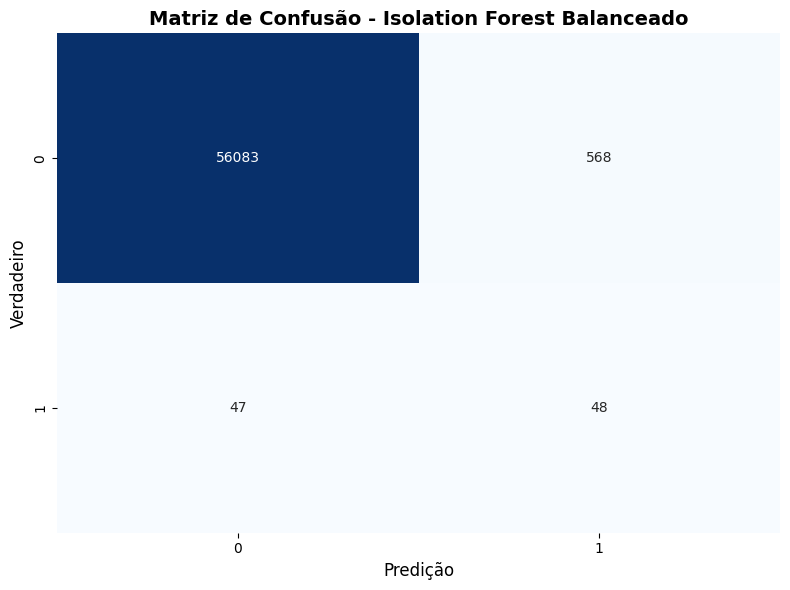

In [20]:
y_pred_balanced_binary = np.where(y_pred_balanced == -1, 1, 0)
cm_balanced = confusion_matrix(y_test, y_pred_balanced_binary)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusão - Isolation Forest Balanceado', fontsize=14, fontweight='bold')
plt.ylabel('Verdadeiro', fontsize=12)
plt.xlabel('Predição', fontsize=12)
plt.tight_layout()
plt.show()

# Isolation Forest com SMOTE

In [21]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Antes do SMOTE - Normal: {np.sum(y_train == 0)}, Fraude: {np.sum(y_train == 1)}")
print(f"Depois do SMOTE - Normal: {np.sum(y_train_smote == 0)}, Fraude: {np.sum(y_train_smote == 1)}")

Antes do SMOTE - Normal: 226602, Fraude: 378
Depois do SMOTE - Normal: 226602, Fraude: 226602


In [23]:
iso_smote = IsolationForest(
    contamination=0.5,
    random_state=42,
    n_estimators=100
)

In [24]:
iso_smote.fit(X_train_smote)
y_pred_smote = iso_smote.predict(X_test)
scores_smote = iso_smote.decision_function(X_test)

In [25]:
print(f"Anomalias detectadas com SMOTE: {np.sum(y_pred_smote == -1)}")

Anomalias detectadas com SMOTE: 19317


In [26]:
results_smote = calculate_metrics(y_test, y_pred_smote, "Isolation Forest com SMOTE")
print("Resultados com SMOTE:")
print(results_smote)

Resultados com SMOTE:
{'Modelo': 'Isolation Forest com SMOTE', 'Precision': 0.0038308225914997153, 'Recall': 0.7789473684210526, 'F1': 0.007624150010302906}


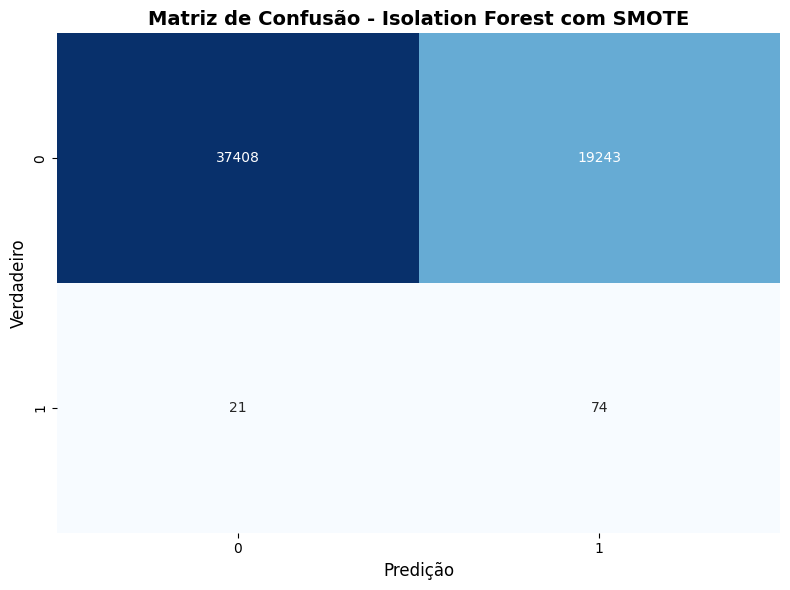

In [27]:
y_pred_smote_binary = np.where(y_pred_smote == -1, 1, 0)
cm_smote = confusion_matrix(y_test, y_pred_smote_binary)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusão - Isolation Forest com SMOTE', fontsize=14, fontweight='bold')
plt.ylabel('Verdadeiro', fontsize=12)
plt.xlabel('Predição', fontsize=12)
plt.tight_layout()
plt.show()

# Isolation Forest com Hiperparâmetros
- `n_estimators`: número de árvores de isolamento
- `max_samples`: número de amostras para treinar cada árvore
- `contamination`: proporção esperada de anomalias

In [28]:
iso_tuned = IsolationForest(
    contamination=0.005,
    n_estimators=200,
    max_samples=256,
    random_state=42
)

In [29]:
iso_tuned.fit(X_train)
y_pred_tuned = iso_tuned.predict(X_test)
scores_tuned = iso_tuned.decision_function(X_test)

In [30]:
print(f"Anomalias detectadas (ajustado): {np.sum(y_pred_tuned == -1)}")

Anomalias detectadas (ajustado): 285


In [31]:
results_tuned = calculate_metrics(y_test, y_pred_tuned, "Isolation Forest Ajustado")
print("Resultados com Hiperparâmetros Ajustados:")
print(results_tuned)

Resultados com Hiperparâmetros Ajustados:
{'Modelo': 'Isolation Forest Ajustado', 'Precision': 0.1368421052631579, 'Recall': 0.4105263157894737, 'F1': 0.20526315789473684}


# Isolation Forest Optuna

Otimizando hiperparâmetros usando uma pequena amostra rotulada

In [32]:
def objective(trial):
    contamination = trial.suggest_float('contamination', 0.001, 0.02)
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_samples = trial.suggest_int('max_samples', 100, 500)
    
    model = IsolationForest(
        contamination=contamination,
        n_estimators=n_estimators,
        max_samples=max_samples,
        random_state=42
    )
    
    model.fit(X_train)
    y_pred = model.predict(X_test)
    y_pred_binary = np.where(y_pred == -1, 1, 0)
    
    f1 = f1_score(y_test, y_pred_binary, zero_division=0)
    
    return f1

In [33]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Melhores parâmetros:")
print(study.best_params)
print(f"Melhor F1-Score: {study.best_value:.4f}")

[I 2025-12-10 10:23:22,212] A new study created in memory with name: no-name-eeb66e1f-9cc9-4726-9a14-9b4b5ce24b47
Best trial: 0. Best value: 0.107973:   2%|▏         | 1/50 [00:04<03:24,  4.18s/it]

[I 2025-12-10 10:23:26,410] Trial 0 finished with value: 0.1079734219269103 and parameters: {'contamination': 0.018335983944989028, 'n_estimators': 111, 'max_samples': 321}. Best is trial 0 with value: 0.1079734219269103.


Best trial: 1. Best value: 0.176471:   4%|▍         | 2/50 [00:11<04:35,  5.74s/it]

[I 2025-12-10 10:23:33,247] Trial 1 finished with value: 0.17647058823529413 and parameters: {'contamination': 0.005973703208604911, 'n_estimators': 206, 'max_samples': 355}. Best is trial 1 with value: 0.17647058823529413.


Best trial: 1. Best value: 0.176471:   6%|▌         | 3/50 [00:20<05:42,  7.28s/it]

...

[I 2025-12-10 10:25:55,901] Trial 47 finished with value: 0.17706237424547283 and parameters: {'contamination': 0.006810380318476318, 'n_estimators': 126, 'max_samples': 451}. Best is trial 41 with value: 0.27555555555555555.


Best trial: 41. Best value: 0.275556:  98%|█████████▊| 49/50 [02:36<00:03,  3.22s/it]

[I 2025-12-10 10:25:59,022] Trial 48 finished with value: 0.21468926553672316 and parameters: {'contamination': 0.00142610585531874, 'n_estimators': 143, 'max_samples': 420}. Best is trial 41 with value: 0.27555555555555555.


Best trial: 41. Best value: 0.275556: 100%|██████████| 50/50 [02:41<00:00,  3.23s/it]

[I 2025-12-10 10:26:03,554] Trial 49 finished with value: 0.22794117647058823 and parameters: {'contamination': 0.0030725818553854123, 'n_estimators': 207, 'max_samples': 481}. Best is trial 41 with value: 0.27555555555555555.
Melhores parâmetros:
{'contamination': 0.0021682853907684123, 'n_estimators': 108, 'max_samples': 415}
Melhor F1-Score: 0.2756


In [34]:
iso_optuna = IsolationForest(
    **study.best_params,
    random_state=42
)

In [35]:
iso_optuna.fit(X_train)
y_pred_optuna = iso_optuna.predict(X_test)
scores_optuna = iso_optuna.decision_function(X_test)

In [36]:
print(f"Anomalias detectadas (Optuna): {np.sum(y_pred_optuna == -1)}")

Anomalias detectadas (Optuna): 130


In [37]:
results_optuna = calculate_metrics(y_test, y_pred_optuna, "Isolation Forest Optuna")
print("Resultados com Optuna:")
print(results_optuna)

Resultados com Optuna:
{'Modelo': 'Isolation Forest Optuna', 'Precision': 0.23846153846153847, 'Recall': 0.3263157894736842, 'F1': 0.27555555555555555}


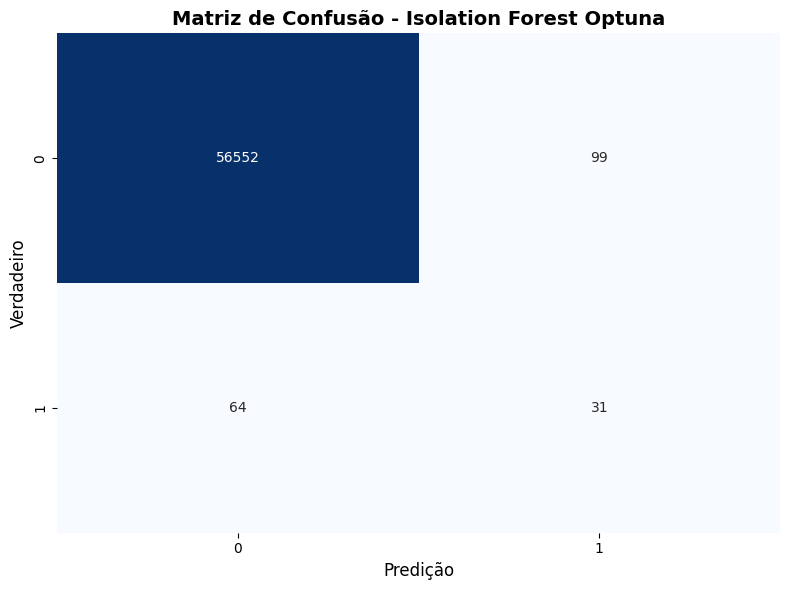

In [38]:
y_pred_optuna_binary = np.where(y_pred_optuna == -1, 1, 0)
cm_optuna = confusion_matrix(y_test, y_pred_optuna_binary)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_optuna, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusão - Isolation Forest Optuna', fontsize=14, fontweight='bold')
plt.ylabel('Verdadeiro', fontsize=12)
plt.xlabel('Predição', fontsize=12)
plt.tight_layout()
plt.show()

# Comparação de Resultados

In [39]:
all_results = pd.DataFrame([
    results_normal,
    results_balanced,
    results_smote,
    results_tuned,
    results_optuna
])

In [40]:
all_results

,Modelo,Precision,Recall,F1
0,Isolation Forest Normal,0.183673,0.189474,0.186528
1,Isolation Forest Balanceado,0.077922,0.505263,0.135021
2,Isolation Forest com SMOTE,0.003831,0.778947,0.007624
3,Isolation Forest Ajustado,0.136842,0.410526,0.205263
4,Isolation Forest Optuna,0.238462,0.326316,0.275556


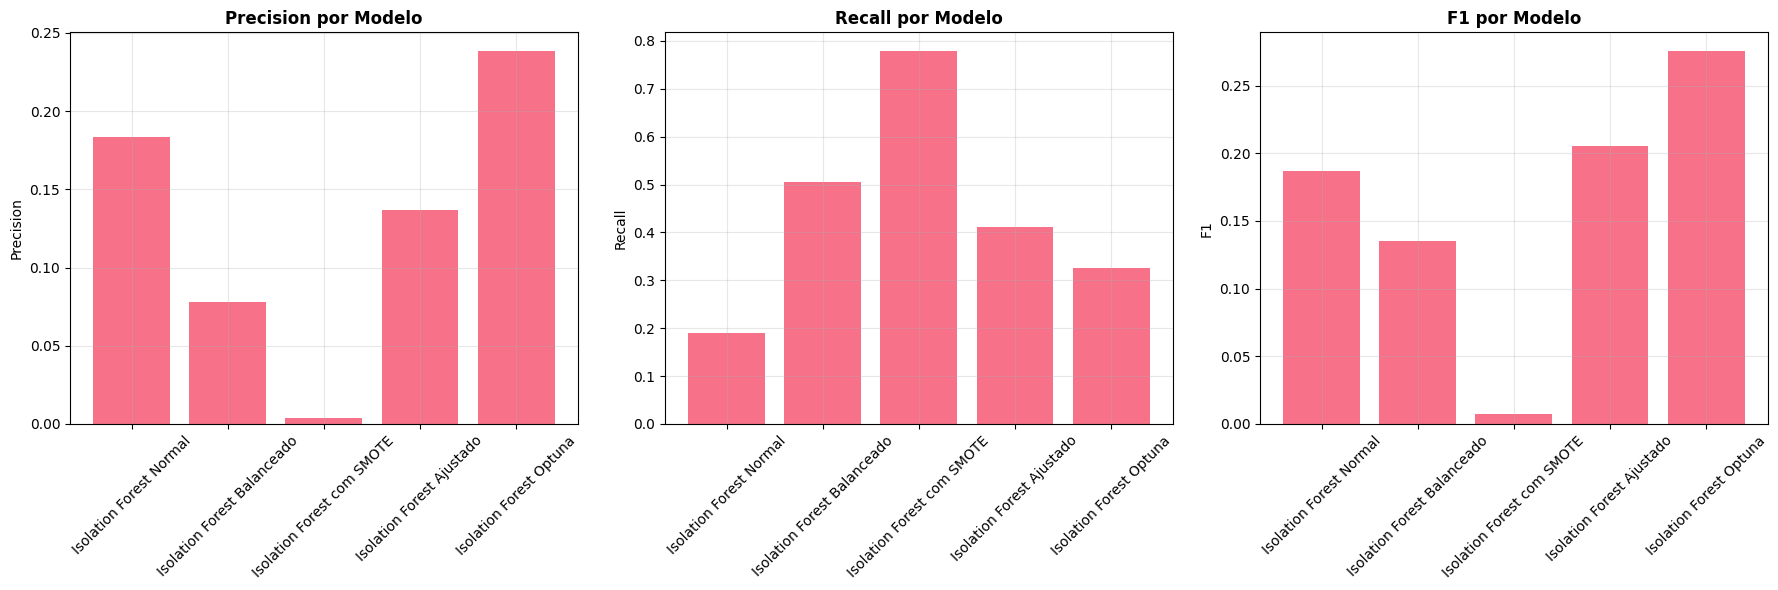

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = ['Precision', 'Recall', 'F1']
for i, metric in enumerate(metrics):
    axes[i].bar(all_results['Modelo'], all_results[metric])
    axes[i].set_title(f'{metric} por Modelo', fontweight='bold')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análise dos Scores de Anomalia

**Interpretação dos scores:**
- Scores **negativos** → maior probabilidade de ser anomalia
- Scores **positivos** → maior probabilidade de ser normal

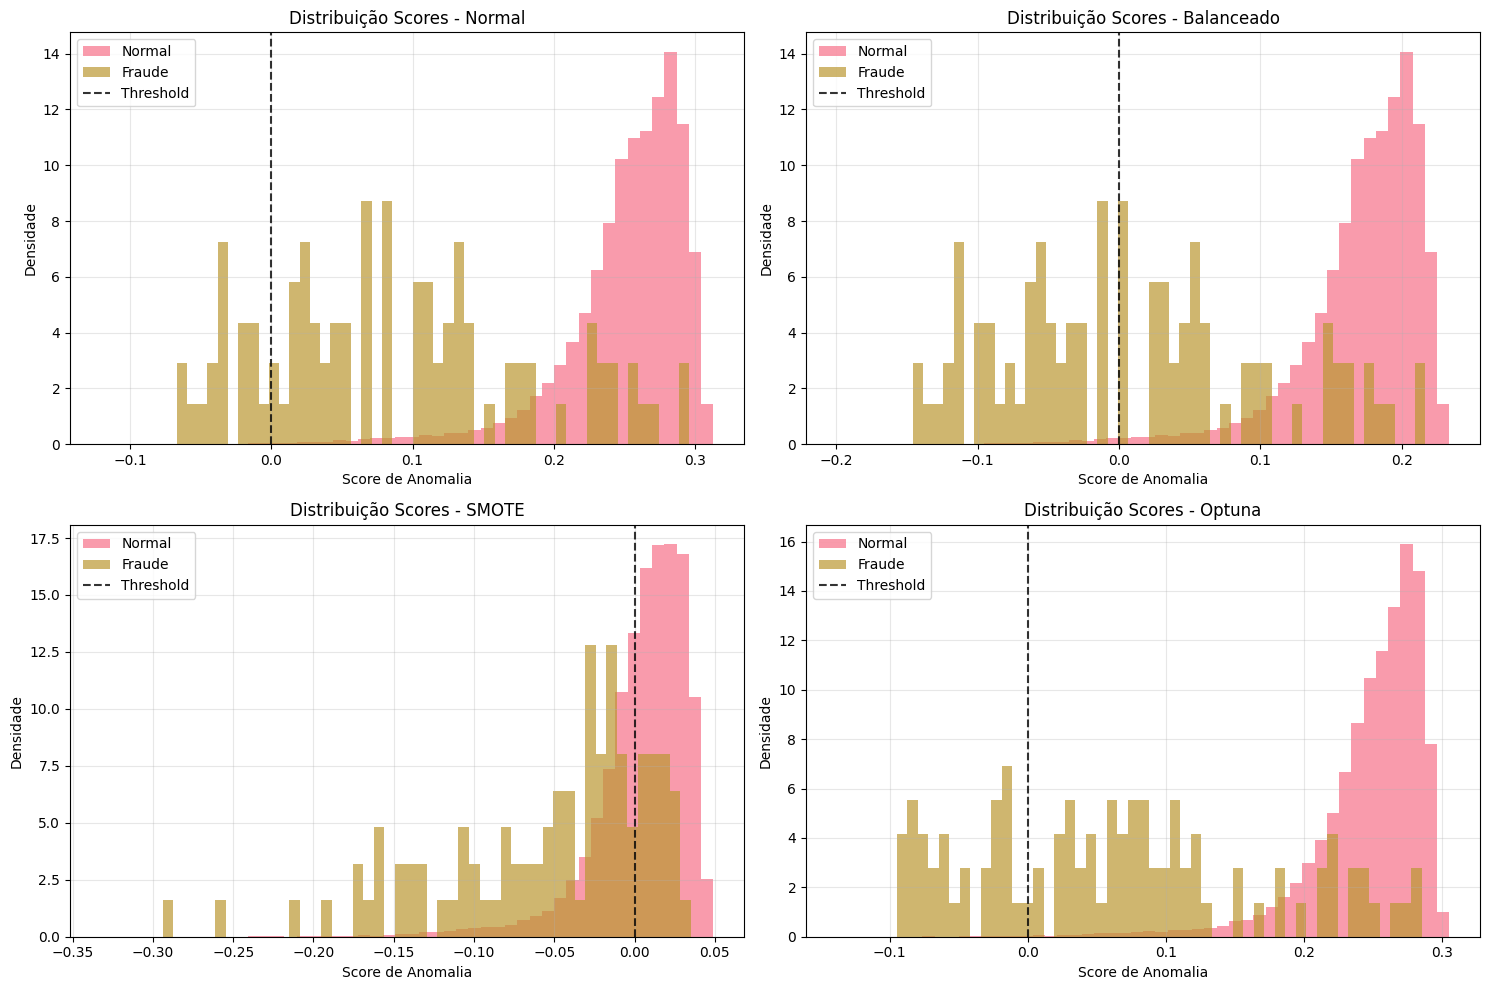

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

models_scores = [
    (scores_normal, 'Normal'),
    (scores_balanced, 'Balanceado'),
    (scores_smote, 'SMOTE'),
    (scores_optuna, 'Optuna')
]

for i, (scores, title) in enumerate(models_scores):
    ax = axes[i//2, i%2]
    
    ax.hist(scores[y_test==0], alpha=0.7, label='Normal', bins=50, density=True)
    ax.hist(scores[y_test==1], alpha=0.7, label='Fraude', bins=50, density=True)
    
    ax.axvline(0, color='black', linestyle='--', alpha=0.8, label='Threshold')
    ax.set_title(f'Distribuição Scores - {title}')
    ax.set_xlabel('Score de Anomalia')
    ax.set_ylabel('Densidade')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# selecionar features que sabe que tem mais outlier (da análise exploratória)